In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import os 
import sys
import matplotlib.pyplot as plt
import pynapple as nap
import numpy as np
sys.path.append("..")

import hippocampalseq as hse
import hippocampalseq._preprocessing as hsep
import hippocampalseq.plotting as hsepl
import hippocampalseq.models as hsem 
import hippocampalseq.utils as hseu

In [53]:
time_window_ms = 20
time_window_s  = time_window_ms / 1000
time_window_advance_ms = 10#time_window_ms
time_window_advance_s = time_window_advance_ms / 1000
bin_size = 2

data_path = os.path.realpath("../data")
rat_name = "Janni"
session = 1
track_type = "Open"
results_path = f"../results/{rat_name}/{track_type}{session}"

In [35]:
(
    raw_position,
    running_position,
    raw_spikes,
    running_spike_info,
    running_spikes,
    excitatory_neurons,
    inhibitory_neurons,
) = hsep.load_clean_data(
    data_path=data_path,
    rat_name=rat_name,
    session=session,
    track_type=track_type,
    ripple_type="awake",
)

/endosome/work/bioinformatics/s440865/hippocampalswr/notebooks/../hippocampalseq/_preprocessing/load_data.py:134: UserWarning: Check the number of epochs in rt
  warnings.warn("Check the number of epochs in rt")


In [48]:
place_fields, place_cell_ids = hsep.calculate_placefields(
    running_position,
    running_spike_info,
    running_spikes,
    excitatory_neurons,
    #environment_size=(0,0,200,200),
    environment_size=None,
    track_type='Open',
    posterior=False
)

[  1.001   3.001   5.001   7.001   9.001  11.001  13.001  15.001  17.001
  19.001  21.001  23.001  25.001  27.001  29.001  31.001  33.001  35.001
  37.001  39.001  41.001  43.001  45.001  47.001  49.001  51.001  53.001
  55.001  57.001  59.001  61.001  63.001  65.001  67.001  69.001  71.001
  73.001  75.001  77.001  79.001  81.001  83.001  85.001  87.001  89.001
  91.001  93.001  95.001  97.001  99.001 101.001 103.001 105.001 107.001
 109.001 111.001 113.001 115.001 117.001 119.001 121.001 123.001 125.001
 127.001 129.001 131.001 133.001 135.001 137.001 139.001 141.001 143.001
 145.001 147.001 149.001 151.001 153.001 155.001 157.001 159.001 161.001
 163.001 165.001 167.001 169.001 171.001 173.001 175.001 177.001 179.001
 181.001 183.001 185.001 187.001 189.001 191.001 193.001 195.001 197.001]
(96, 99)


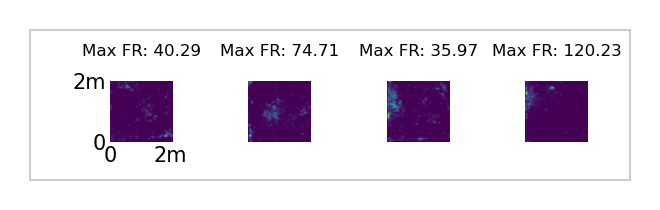

In [49]:
if place_fields.shape[-1] == 1:
    hsepl.plot_linear_placefields(None, place_fields, figsize=(8,8))
else:
    hsepl.plot_open_placefields(place_fields, pfs=[0,1,2,3])

In [58]:
tt = np.concat([
    t[None,...] for _,t in tc[0].items()
],axis=0)
tt[~np.isfinite(tt)] = 0.0
tt.shape

(149, 100, 100)

In [54]:
true_trajectories, spikemats = hsep.process_theta(
    running_position,
    running_spikes,
    place_cell_ids,
    time_window_ms=time_window_ms,
    time_window_advance_ms=time_window_advance_ms
)

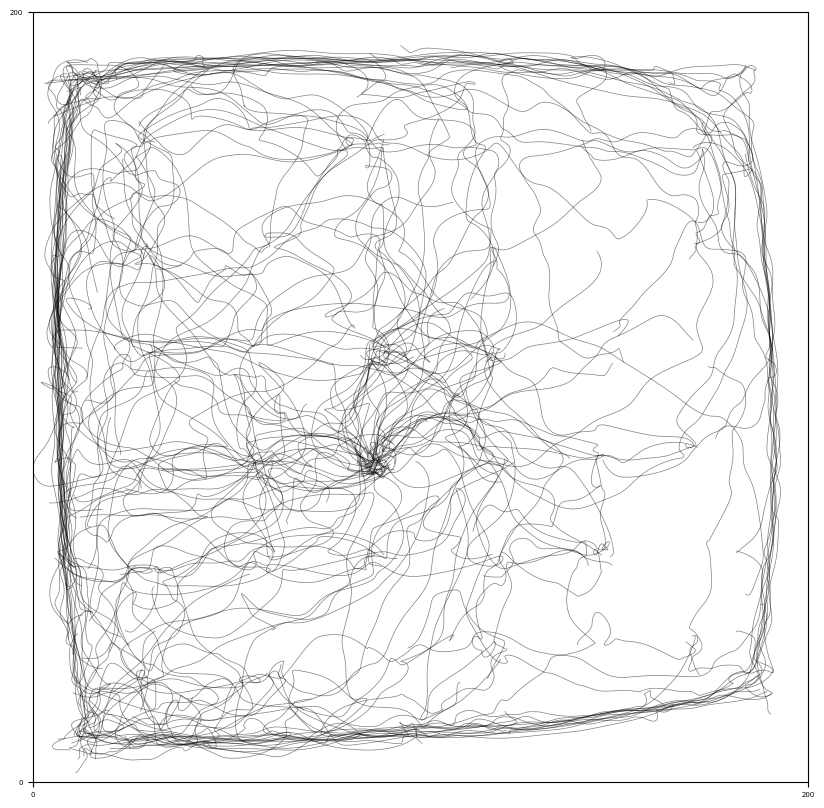

In [41]:
plt.figure(figsize=(10,10))
hse.plot_trajectories(true_trajectories)

In [ ]:
tc = nap.compute_tuning_curves(
    running_spikes,
    running_position[['x','y']],
    (100,100)
)
start = np.min([np.min(s) for s in running_spikes])
end = np.max([np.max(s) for s in running_spikes])
decoded_trajectory = nap.decode_bayes(
    tc, running_spikes,
    nap.IntervalSet(start=start, end=end), 2
)

In [55]:
decoder = hsem.BayesianMAP(place_fields, time_window_s, bin_size)
decoded_trajectory = decoder.fit(spikemats,).trajectories

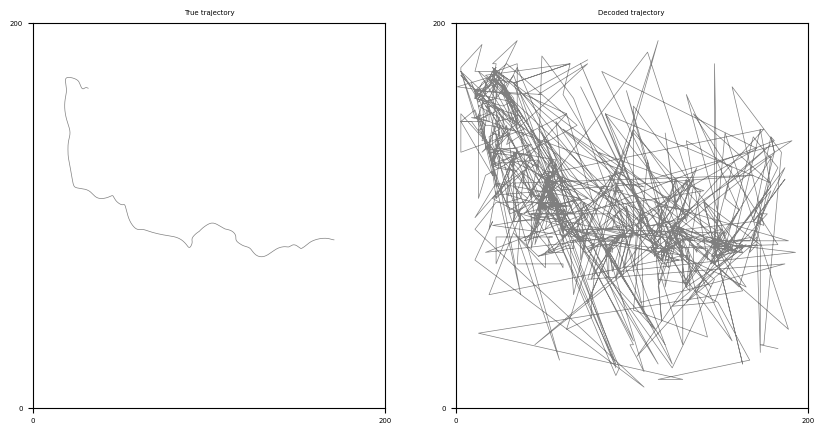

In [60]:
num = 76
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("True trajectory")
hse.plot_trajectories([true_trajectories[num]])
plt.subplot(1,2,2)
plt.title("Decoded trajectory")
hse.plot_trajectories([decoded_trajectory[num]])